In [40]:
import pandas as pd

In [41]:
import numpy as np

In [42]:

df = pd.read_csv('../data/Telco-Customer-Churn-cleaned.csv')

In [43]:
df.groupby('Churn')['tenure'].mean()

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

In [44]:
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

In [45]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [46]:
pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [47]:
result = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100
result.round(2).reset_index()

Churn,PaymentMethod,No,Yes
0,Bank transfer (automatic),83.29,16.71
1,Credit card (automatic),84.76,15.24
2,Electronic check,54.71,45.29
3,Mailed check,80.89,19.11


In [48]:
df.select_dtypes(include=['int64', 'float64']).columns

Index(['Unnamed: 0', 'SeniorCitizen', 'tenure', 'MonthlyCharges',
       'TotalCharges'],
      dtype='object')

In [49]:
df['Churn_numeric'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [50]:
numeric_df = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_numeric']]
correlation_matrix = numeric_df.corr()
correlation_matrix

,tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Churn_numeric
tenure,1.000000,0.247900,0.826178,0.016567,-0.352229
MonthlyCharges,0.247900,1.000000,0.651174,0.220173,0.193356
TotalCharges,0.826178,0.651174,1.000000,0.103006,-0.198324
SeniorCitizen,0.016567,0.220173,0.103006,1.000000,0.150889
Churn_numeric,-0.352229,0.193356,-0.198324,0.150889,1.000000


In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

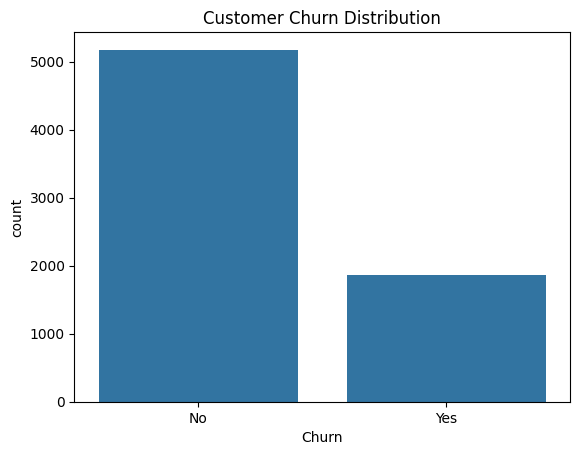

In [52]:
sns.countplot(data=df, x='Churn')
plt.title('Customer Churn Distribution')
plt.show()

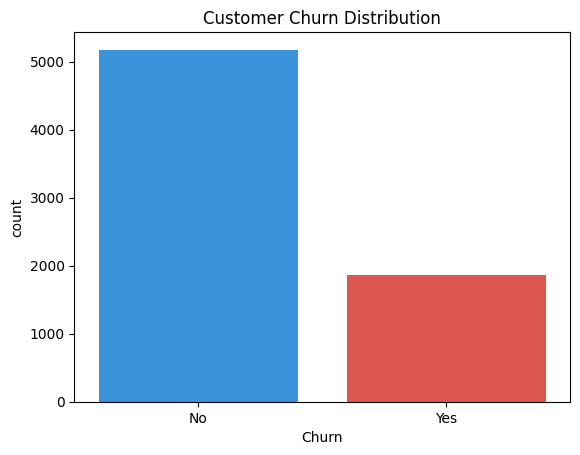

In [54]:
sns.countplot(data=df, x='Churn', hue='Churn', palette=['#2196F3','#F44336'])
plt.title('Customer Churn Distribution')
plt.show()

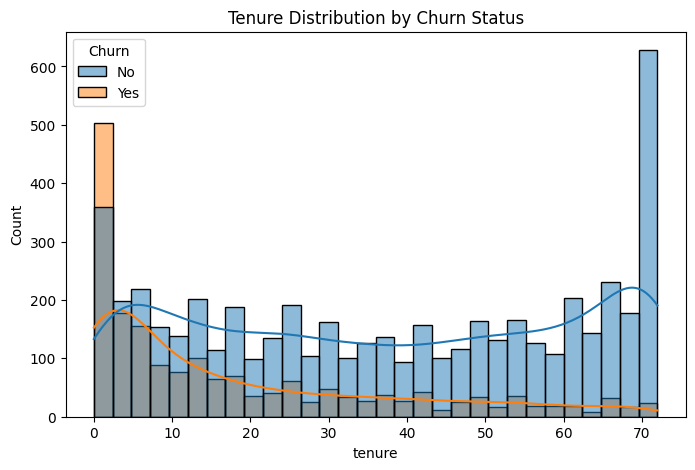

In [58]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True)
plt.title('Tenure Distribution by Churn Status')
plt.show()

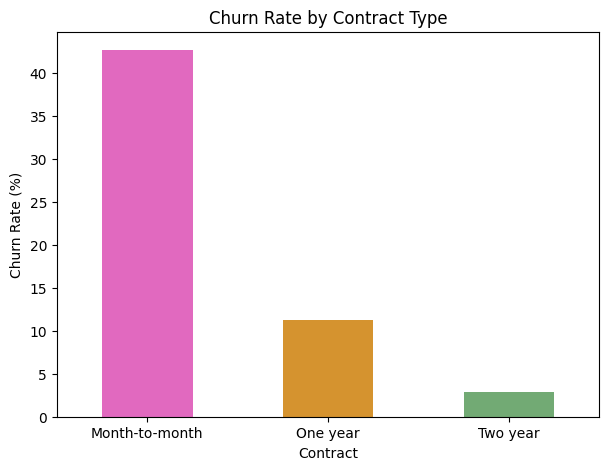

In [67]:
churn_by_contract = df.groupby('Contract')['Churn_numeric'].mean() * 100

plt.figure(figsize=(7,5))
churn_by_contract.plot(kind='bar', color=["#E169BF","#D5932F","#72AA74"])
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

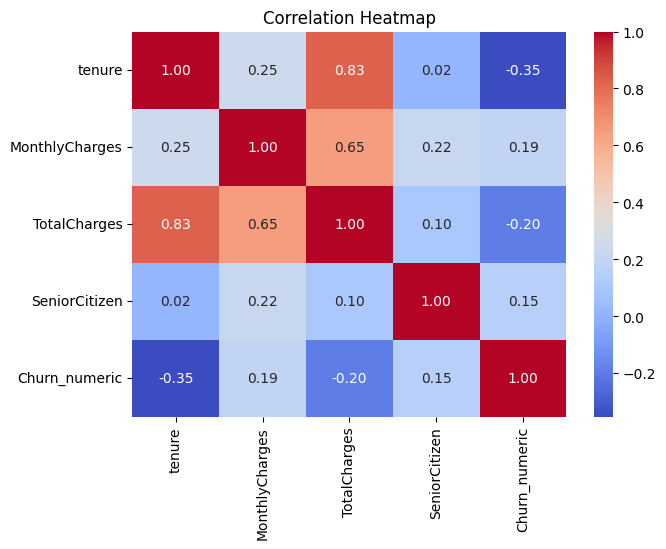

In [70]:
plt.figure(figsize=(7,5))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()